In [1]:
%load_ext autoreload
%autoreload 2

In [2]:

from mad.objs.planets import Planet, PlanetConfig
from mad.objs import Radar, RadarConfig
import matplotlib.pyplot as plt

import numpy as np

from mad.configs.planets import EARTH_SETTINGS

In [3]:
EARTH_SETTINGS["radius"] = 100.0

earth = Planet(PlanetConfig(**EARTH_SETTINGS))

random_pos = earth.create_2D_point(altitude=5.0)
target1 = earth.create_2D_point_at_distance(random_pos, distance_km=0.02, name="Target1")
target2 = earth.create_2D_point_at_distance(random_pos, distance_km=0.2, name="Target2")

radar_cfg = RadarConfig(
    position = random_pos.position,
    range=45.0,
    name="TestRadar",
    voxel_size=9.0
)

radar = Radar(radar_cfg, earth)

In [7]:
radar.detection_voxels

{(np.int64(-7), np.int64(9), np.int64(-2)): 0.19999999999999996,
 (np.int64(-7), np.int64(9), np.int64(-1)): 0.19999999999999996,
 (np.int64(-7), np.int64(9), np.int64(0)): 0.19999999999999996,
 (np.int64(-7), np.int64(9), np.int64(1)): 0.19999999999999996,
 (np.int64(-7), np.int64(10), np.int64(-3)): 0.19999999999999996,
 (np.int64(-7), np.int64(10), np.int64(-2)): 0.19999999999999996,
 (np.int64(-7), np.int64(10), np.int64(-1)): 0.19999999999999996,
 (np.int64(-7), np.int64(10), np.int64(0)): 0.19999999999999996,
 (np.int64(-7), np.int64(10), np.int64(1)): 0.19999999999999996,
 (np.int64(-7), np.int64(10), np.int64(2)): 0.19999999999999996,
 (np.int64(-7), np.int64(11), np.int64(-3)): 0.19999999999999996,
 (np.int64(-7), np.int64(11), np.int64(-2)): 0.19999999999999996,
 (np.int64(-7), np.int64(11), np.int64(-1)): 0.19999999999999996,
 (np.int64(-7), np.int64(11), np.int64(0)): 0.19999999999999996,
 (np.int64(-7), np.int64(11), np.int64(1)): 0.19999999999999996,
 (np.int64(-7), np.in

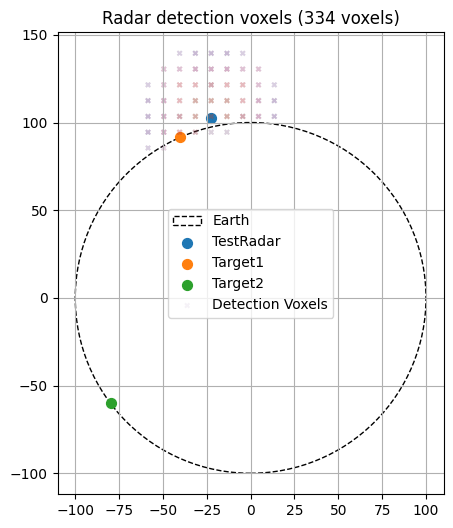

In [12]:
fig, ax = plt.subplots(figsize=(6, 6))
earth.plot_2D_with_points([radar, target1, target2], display="planet", ax=ax)

# Convert voxel grid keys to world-space voxel centres for plotting
voxel_keys = np.array(list(radar.detection_voxels.keys()))
voxel_centers = (voxel_keys + 0.5) * radar.voxel_size
c_value = list(radar.detection_voxels.values())

ax.scatter(voxel_centers[:, 0], voxel_centers[:, 1], 
           c=c_value, marker='x', s=10, cmap="inferno",
           alpha=0.05, label='Detection Voxels')
ax.legend()
plt.title(f"Radar detection voxels ({len(radar.detection_voxels)} voxels)")
plt.show()

In [13]:
radar.detect(target1), radar.detect(target2)

(True, False)

In [14]:
radar.get_detection_strength(target1), radar.get_detection_strength(target2)

(0.6, 0.0)